Module 10 Case study 1

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

In [2]:
df= pd.read_csv('Datasets/additional_resources_10_6qt_ynxafhm/driver-data.csv')
df

,id,mean_dist_day,mean_over_speed_perc
0,3423311935,71.24,28
1,3423313212,52.53,25
2,3423313724,64.54,27
3,3423311373,55.69,22
4,3423310999,54.58,25
...,...,...,...
3995,3423310685,160.04,10
3996,3423312600,176.17,5
3997,3423312921,170.91,12
3998,3423313630,176.14,5


In [ ]:
# Fields in Data
# • id: Unique Id of the driver 
# • mean_dist_day: Mean distance driven by driver per day
# • mean_over_speed_perc: Mean percentage of time a driver was > 5 mph over the speed limit

In [3]:
print(df.duplicated().sum())

df.isnull().sum()

0


id                      0
mean_dist_day           0
mean_over_speed_perc    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4000 non-null   int64  
 1   mean_dist_day         4000 non-null   float64
 2   mean_over_speed_perc  4000 non-null   int64  
dtypes: float64(1), int64(2)
memory usage: 93.9 KB


In [8]:
df.describe()

,id,mean_dist_day,mean_over_speed_perc
count,4.000000e+03,4000.000000,4000.000000
mean,3.423312e+09,76.041522,10.721000
std,1.154845e+03,53.469563,13.708543
min,3.423310e+09,15.520000,0.000000
25%,3.423311e+09,45.247500,4.000000
50%,3.423312e+09,53.330000,6.000000
75%,3.423313e+09,65.632500,9.000000
max,3.423314e+09,244.790000,100.000000


In [10]:
df['mean_over_speed_perc'].value_counts()

mean_over_speed_perc
5      553
6      524
4      503
7      366
3      353
      ... 
77       1
100      1
83       1
97       1
73       1
Name: count, Length: 96, dtype: int64

In [41]:
import warnings
warnings.filterwarnings('ignore')

model = KMeans(n_clusters=4)
model.fit(df)

predicted_labels = model.predict(df)

In [42]:
predicted_labels

array([1, 0, 3, ..., 0, 3, 1], shape=(4000,), dtype=int32)

In [43]:

label_counts = pd.DataFrame(predicted_labels)
label_counts.value_counts()

0
2    1012
1    1005
0     996
3     987
Name: count, dtype: int64

In [44]:
model.cluster_centers_

array([[ 3.42331296e+09,  7.39615694e+01,  1.07937626e+01,
         2.65090543e+00,  1.94768612e+00,  1.00000000e+00],
       [ 3.42331196e+09,  7.75689463e+01,  1.09811133e+01,
         3.10139165e+00,  1.03578529e+00,  2.18687873e-02],
       [ 3.42331095e+09,  7.77258876e+01,  1.02011834e+01,
         1.69230769e+00,  2.95069034e+00, -9.99200722e-16],
       [ 3.42331395e+09,  7.48477485e+01,  1.09168357e+01,
         5.05070994e-01, -4.21884749e-15,  1.00000000e+00]])

In [45]:
df['cluster'] = predicted_labels
df['cluster']

0       1
1       0
2       3
3       2
4       2
       ..
3995    2
3996    0
3997    0
3998    3
3999    1
Name: cluster, Length: 4000, dtype: int32

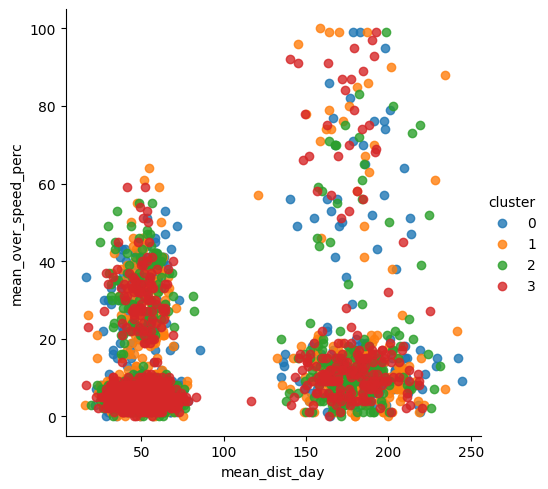

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lmplot(data=df, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster', fit_reg=False)
plt.show()

In [48]:
model.inertia_

345609205.3920677

In [49]:
from sklearn.metrics import silhouette_score

silhouette_score(df,predicted_labels)

np.float64(0.5580939337634921)

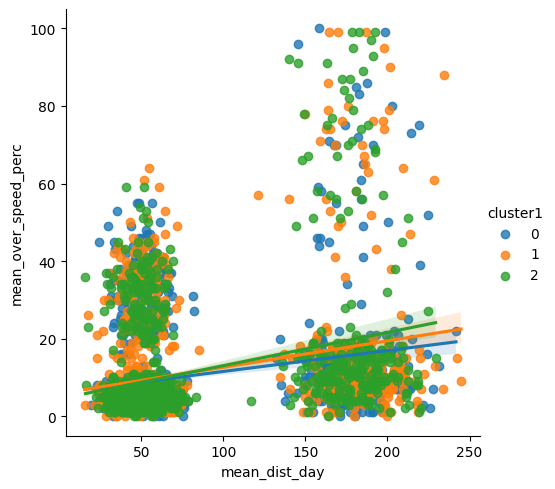

np.float64(0.5813423292957165)

In [50]:
# n_clusters = 3

model1 = KMeans(n_clusters=3)
model1.fit(df)

predicted_labels1 = model1.predict(df)

df['cluster1'] = predicted_labels1

sns.lmplot(data=df, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster1')
plt.show()

silhouette_score(df,predicted_labels1)

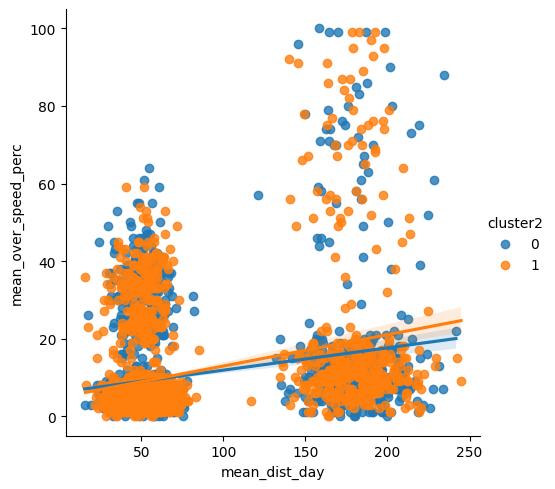

np.float64(0.622320831269932)

In [51]:
# n_clusters = 2

model2 = KMeans(n_clusters=2)
model2.fit(df)

predicted_labels2 = model2.predict(df)

df['cluster2'] = predicted_labels2

sns.lmplot(data=df, x='mean_dist_day', y='mean_over_speed_perc', hue='cluster2')
plt.show()

silhouette_score(df,predicted_labels2)

In [52]:
model2.cluster_centers_

array([[3.42331145e+09, 7.77956431e+01, 1.05802592e+01, 1.50448654e+00,
        3.32502493e-01, 3.98803589e-03],
       [3.42331345e+09, 7.42768455e+01, 1.08625878e+01, 1.49047141e+00,
        1.66599799e+00, 1.00000000e+00]])

In [53]:
df

,id,mean_dist_day,mean_over_speed_perc,cluster,cluster1,cluster2
0,3423311935,71.24,28,1,1,0
1,3423313212,52.53,25,0,2,1
2,3423313724,64.54,27,3,2,1
3,3423311373,55.69,22,2,0,0
4,3423310999,54.58,25,2,0,0
...,...,...,...,...,...,...
3995,3423310685,160.04,10,2,0,0
3996,3423312600,176.17,5,0,1,1
3997,3423312921,170.91,12,0,1,1
3998,3423313630,176.14,5,3,2,1


In [54]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering()

predicted = agglo.fit_predict(df)

In [55]:
predicted

array([0, 1, 1, ..., 0, 1, 0], shape=(4000,))

In [56]:
agglo.n_clusters_

2

In [57]:
silhouette_score(df, predicted)

np.float64(0.5575633653468896)

In [58]:
print('Kmeans algorithm showcased better results with 2 clusters')

Kmeans algorithm showcased better results with 2 clusters
